In [1]:

import os, glob
import json
import numpy 
import tifffile
import random

from matplotlib import pyplot
from skimage.filters import threshold_otsu
from tqdm.auto import tqdm

path = os.path.join("/home-local2", "projects", "FLCDataset", "scraping-confocal-sted")
files = glob.glob(os.path.join(path, "*.tif"))
print(len(files))

metadata = os.path.join(path, "metadata.json")
with open(metadata, "r") as f:
    metadata = json.load(f)
print(len(metadata))

11104
11104


In [2]:
def normalize_image(image):
    m, M = numpy.quantile(image, [0.001, 0.999])
    image = numpy.clip((image - m) / (M - m + 1e-6), 0, 1)
    return image

def load_image(path):
    conf, sted = tifffile.imread(path)

    conf = normalize_image(conf)
    sted = normalize_image(sted)

    return conf, sted

def show_images(images, titles=None, figsize=(10, 5)):
    fig, axes = pyplot.subplots(1, len(images), figsize=figsize)
    for i, image in enumerate(images):
        ax = axes[i] if len(images) > 1 else axes
        ax.imshow(image, cmap='gray')
        ax.axis('off')
        if titles:
            ax.set_title(titles[i])
    pyplot.show()
    

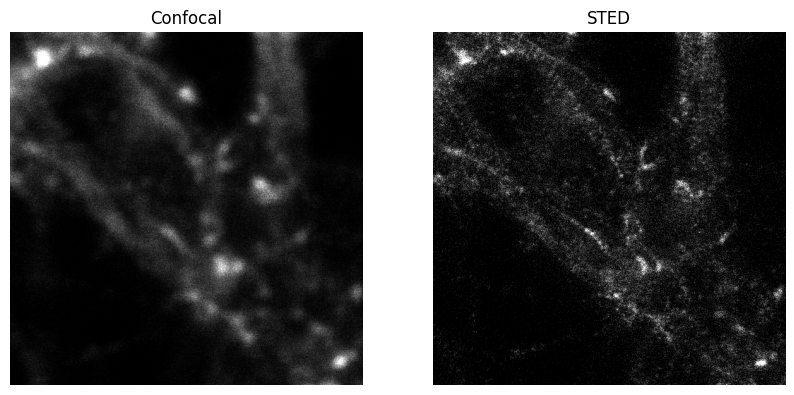

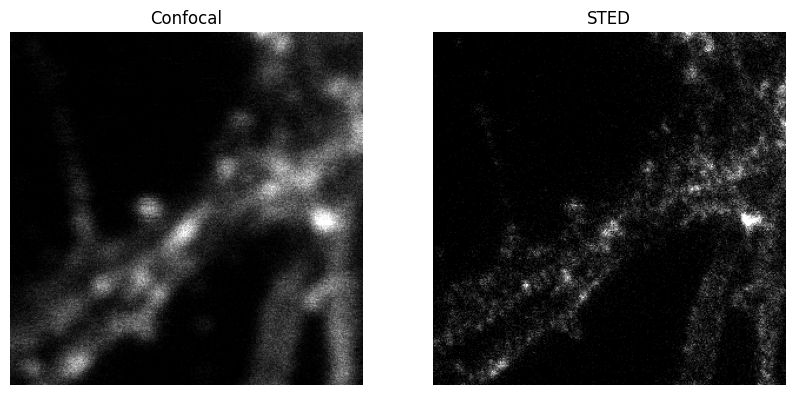

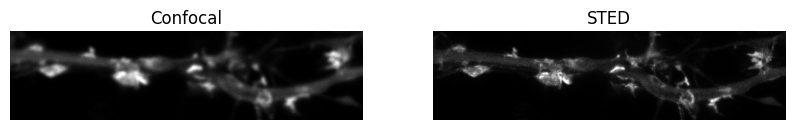

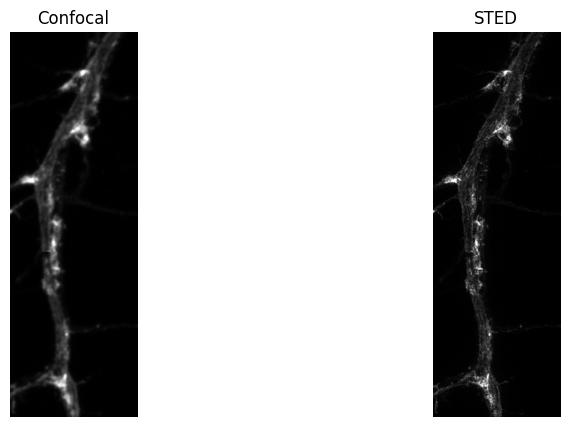

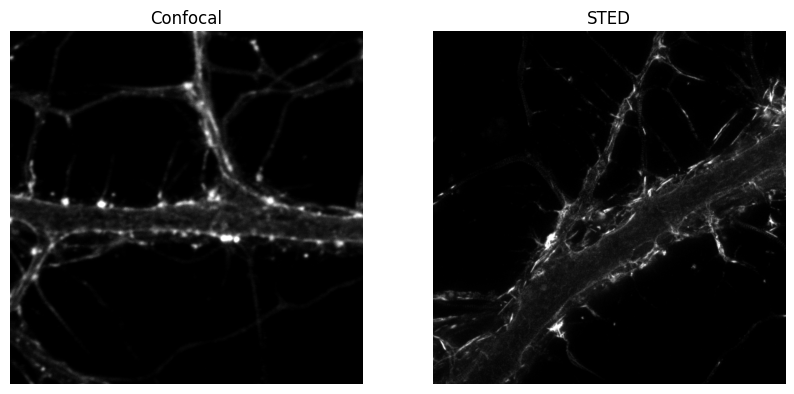

In [11]:
for key in random.choices(list(metadata.keys()), k=5):
    file = os.path.join(path, f"{key}.tif")
    conf, sted = load_image(file)
    show_images([conf, sted], titles=["Confocal", "STED"])

In [20]:
snrs = []
for i, (file) in enumerate(tqdm(files)):

    conf, sted = tifffile.imread(file)
    
    # Normalize image 
    m, M = numpy.quantile(sted, [0.001, 0.999])
    if m == M: 
        continue    
    sted = numpy.clip((sted - m) / (M - m), 0, 1)

    threshold = threshold_otsu(sted)
    foreground = sted > threshold

    std = numpy.std(sted[numpy.invert(foreground)])
    if std == 0:
        continue
    snr = numpy.mean(sted[foreground]) / std

    snrs.append({
        "key" : os.path.basename(file),
        "snr" : snr
    })


  0%|          | 0/16243 [00:00<?, ?it/s]

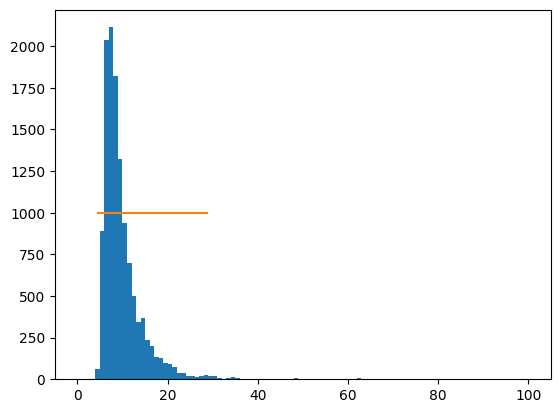

In [22]:
values = numpy.array([s["snr"] for s in snrs])
fig, ax = pyplot.subplots()
ax.hist(values, range=(0, 100), bins=100)
mean, std = numpy.mean(values), numpy.std(values)

median = numpy.median(values)
iqr = numpy.quantile(values, 0.75) - numpy.quantile(values, 0.25)

ax.plot([median - iqr, numpy.quantile(values, 0.99)], [1000, 1000])
pyplot.show()


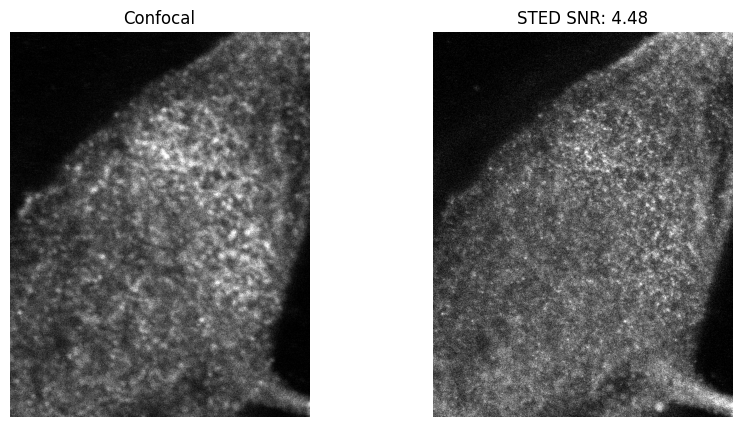

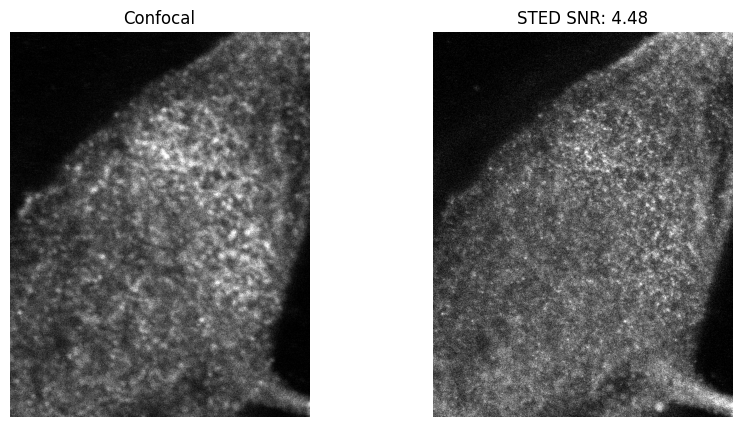

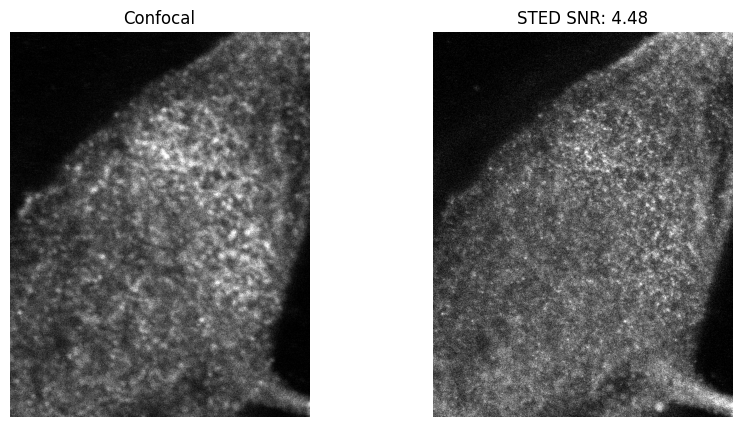

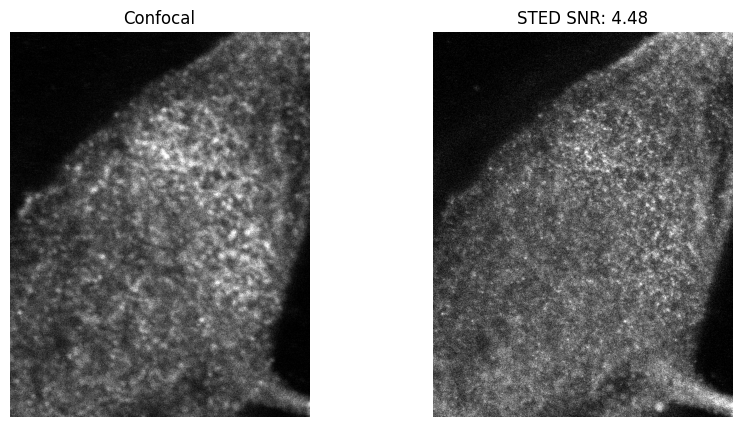

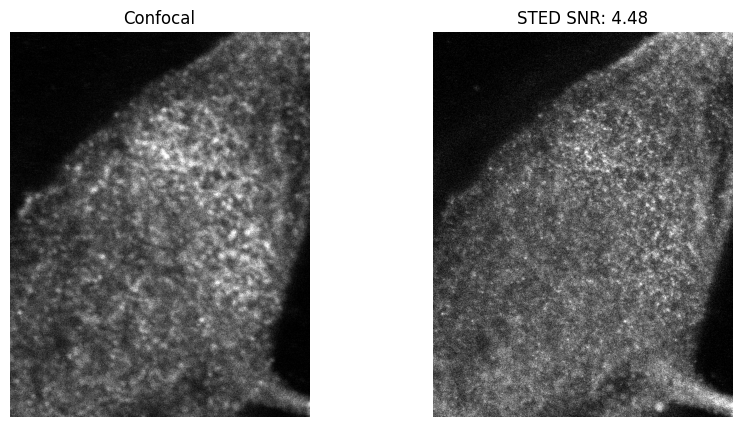

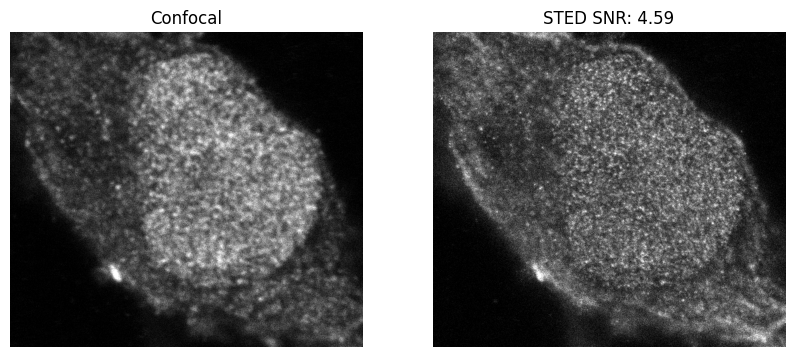

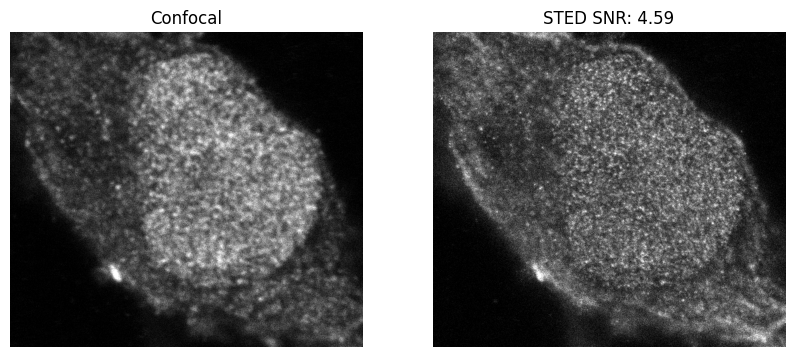

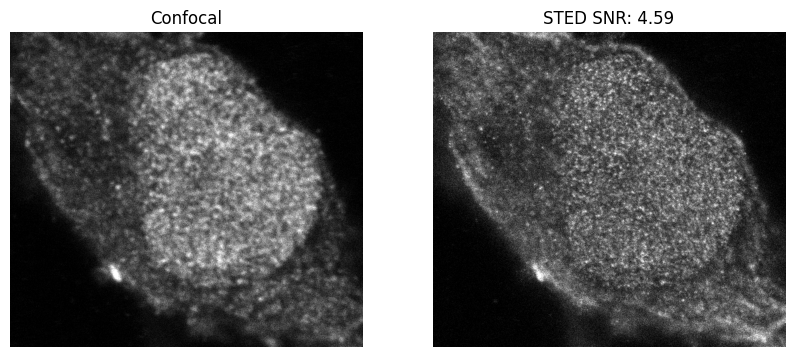

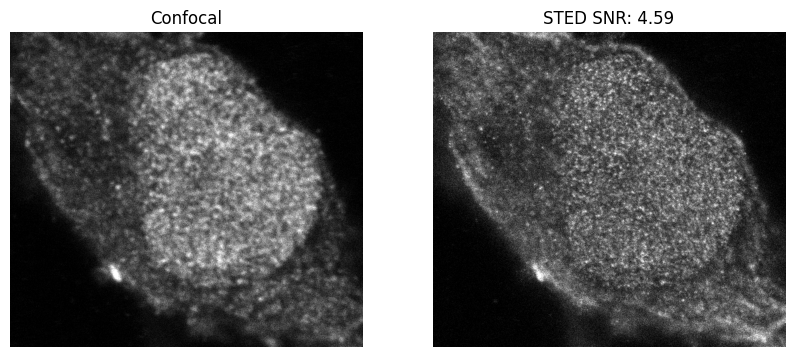

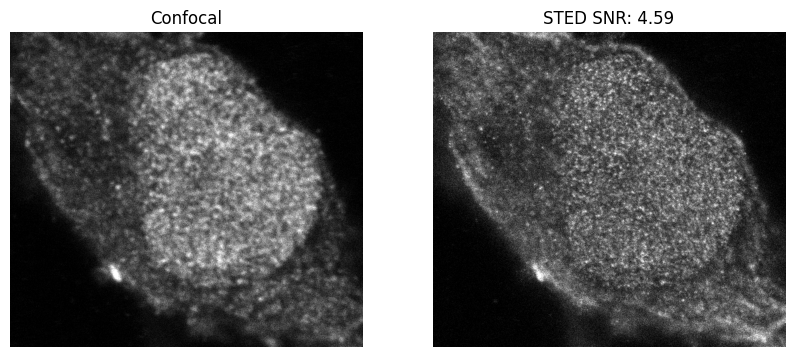

In [28]:
argwhere = numpy.argwhere(values > numpy.quantile(values, 0.99))

# numpy.random.shuffle(argwhere)
# for i in argwhere[:10]:
#     i = i.item()
#     file = os.path.join(path, snrs[i]["key"])
#     conf, sted = load_image(file)
#     show_images([conf, sted], titles=["Confocal", "STED SNR: %.2f" % values[i]])

argwhere = numpy.argsort(values)
for i in argwhere[:10]:
    i = i.item()
    file = os.path.join(path, snrs[i]["key"])
    conf, sted = load_image(file)
    show_images([conf, sted], titles=["Confocal", "STED SNR: %.2f" % values[i]])

In [ ]:
argwhere = numpy.argwhere(values < numpy.quantile(values, 0.99))
updated_metadata = {}
for i in argwhere:
    i = i.item()
    key = snrs[i]["key"]
    updated_metadata[key] = metadata[key]
print(len(metadata), len(updated_metadata))

# metadata = json.dump(updated_metadata, open(os.path.join(".", "datasets", "scraping", "metadata-updated.json"), "w"))

46671 37387
